In [1]:
from skimage.metrics import structural_similarity as ssim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch import nn
import matplotlib.pyplot as plt
import torchvision
import torch.optim as optim
import torch.nn.functional as F
from tqdm import tqdm
import torch

# TODO: https://medium.com/@whyamit101/latent-space-representations-in-variational-autoencoders-vaes-e74076eda77b
# from sklearn.decomposition import PCA

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [3]:
# Params
batch_size = 128
learning_rate = 2e-4
# num_epochs = 30
num_epochs = 10
channels = 3
latent_dim = 32
num_embeddings = 512  # Number of vectors in the codebook
beta = 0.4  # Beta, the commitment loss weight
num_residual_hiddens = 3
num_residual_layers = latent_dim // 2

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((25, 25)),
])

train_dataset = datasets.SVHN(root='./data', split="train", transform=transform, download=True)
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)

In [5]:
def show_image(batch_of_tensors):
    images = batch_of_tensors[:4]
    print(f"Plotting image shape: {images[0].shape}")

    grid_img = torchvision.utils.make_grid(images, nrow=2)

    grid_img = grid_img.detach().cpu()

    plt.figure(figsize=(2,2))
    plt.imshow(grid_img.permute(1,2,0), cmap='gray')
    plt.axis("off")
    plt.show()

In [6]:
class VQEmbedding(nn.Module):
    def __init__(self, num_embeddings, embedding_dim):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.num_embeddings = num_embeddings

        self.embedding = nn.Embedding(num_embeddings, embedding_dim)
        self.embedding.weight.data.uniform_(-1/self.num_embeddings, 1/self.num_embeddings)

    def forward(self, z):
        # b = batch size
        # c = number of channels
        # h = height
        # w = width
        b, c, h, w = z.shape
        z_channel_last = z.permute(0, 2, 3, 1)
        z_flattened = z_channel_last.reshape(b*h*w, self.embedding_dim)

        # Calculate distances between z and the codebook embeddings |a-b|²
        # Euclidean distance. Form applied for efficiency in deep learning. In literature l2 distance is used.
        distances = (
            torch.sum(z_flattened ** 2, dim=-1, keepdim=True)                 # a²
            + torch.sum(self.embedding.weight.t() ** 2, dim=0, keepdim=True)  # b²
            - 2 * torch.matmul(z_flattened, self.embedding.weight.t())        # -2ab
        )

        # Get the index with the smallest distance
        # Finds minimum indexes at each row. Uses nearest neigboor look up
        encoding_indices = torch.argmin(distances, dim=-1)

        # Get the quantized vector
        z_q = self.embedding(encoding_indices)
        # when we find the indexes feature vectors, we reshape them to the encoder latent 
        # representation shape
        z_q = z_q.reshape(b, h, w, self.embedding_dim)
        
        # changed the order of the reshaped z_q
        z_q = z_q.permute(0, 3, 1, 2)

        # Calculate the commitment loss
        # Measures how closely the encoder outputs and the selected codebook embeddings match each other.
        reconstruction_loss = F.mse_loss(z_q, z.detach())
        commitment_loss = F.mse_loss(z_q.detach(), z)
        loss = reconstruction_loss + beta * commitment_loss

        # Straight-through estimator trick for gradient backpropagation
        # Finding closer membership to indexes (Straight through loss)
        z_q = z + (z_q - z).detach()

        return z_q, loss, encoding_indices

In [7]:
class Residual(nn.Module):
    """
    Residual Convolutional Layer
    """

    def __init__(self, in_channels, num_hiddens, num_residual_hiddens):
        """
        initialize residual CNN layer

        :param in_channels number: Number of input channels
        :param num_hiddens number: Number of hidden channels
        :param num_residual_hiddens number: Number of residual hiddens
        """
        super(Residual, self).__init__()
        self._block = nn.Sequential(
            nn.ReLU(True),
            # C: 3 -> residual hidden
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=num_residual_hiddens,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False,
            ),
            nn.ReLU(True),
            # C: resiual hidden -> out_hidden
            nn.Conv2d(
                in_channels=num_residual_hiddens,
                out_channels=num_hiddens,
                kernel_size=1,
                stride=1,
                bias=False,
            ),
        )

    def forward(self, x):
        """
        Residual layer

        :param x numpy.ndarray: Input image
        """
        return x + self._block(x)  # residual output


class ResidualStack(nn.Module):
    """
    Residual Convolution Stack
    """

    def __init__(
        self, in_channels, num_hiddens, num_residual_layers, num_residual_hiddens
    ):
        """
        initialize residual stack

        :param in_channels number: Number of input channels
        :param num_hiddens number: Number of hidden channels
        :param num_residual_layers number: Number of residual layers in stack
        :param num_residual_hiddens number: Number of hidden residual channels
        """
        super(ResidualStack, self).__init__()
        self._num_residual_layers = num_residual_layers
        self._layers = nn.ModuleList(
            [
                Residual(in_channels, num_hiddens, num_residual_hiddens)
                for _ in range(self._num_residual_layers)
            ]
        )

    def forward(self, x):
        """
        Apply residual stack

        :param x numpy.ndarray: Input image
        """
        # Apply all residual layers in stack
        for i in range(self._num_residual_layers):
            x = self._layers[i](x)
        return F.relu(x)

In [8]:
class VQVAE(nn.Module):
    def __init__(self):
        super(VQVAE, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(channels, 12, kernel_size=3, stride=2, padding=1),
            ResidualStack(
                in_channels=12,
                num_hiddens=12,
                num_residual_layers=num_residual_layers,
                num_residual_hiddens=num_residual_hiddens,
            ),
            nn.ReLU(),
            nn.Conv2d(12, 24, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(24, latent_dim, kernel_size=3, stride=2, padding=1),
            # nn.ReLU(),
            # nn.Conv2d(48, latent_dim, kernel_size=1)
        )

        # Vector Quantization
        self.vq_layer = VQEmbedding(num_embeddings, latent_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 48, kernel_size=1),
            ResidualStack(
                in_channels=48,
                num_hiddens=48,
                num_residual_layers=num_residual_layers,
                num_residual_hiddens=num_residual_hiddens,
            ),
            nn.ReLU(),
            nn.ConvTranspose2d(48, 24, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            # switches in channels and out channels. (in_channels, out_channels, kH, kW)
            nn.ConvTranspose2d(24, 12, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(12, channels, kernel_size=3, stride=2, padding=1),
            nn.Tanh()  # Output values in range [-1, 1]
        )

    def forward(self, x):
        z_e = self.encoder(x)        
        z_q, vq_loss, _ = self.vq_layer(z_e)
        x_recon = self.decoder(z_q)
        return x_recon, vq_loss

In [9]:
model = VQVAE().to(device)
optimizer = optim.Adam(
    model.parameters(), 
    lr=learning_rate,
    amsgrad=True
)

In [10]:
def _get_vq_loss(recon_x, x, vq_loss):
    recon_loss = F.mse_loss(recon_x, x)
    return recon_loss + vq_loss

Epoch 1/10: 100%|██████████| 573/573 [00:05<00:00, 104.50it/s, Loss=0.0151]


Epoch [1/10] Average Loss: 0.0009
Displaying images (Before/After reconstruction)
Plotting image shape: torch.Size([3, 25, 25])


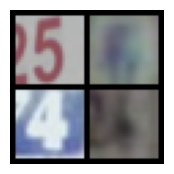

Plotting image shape: torch.Size([3, 25, 25])


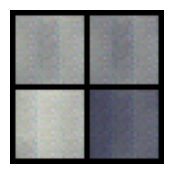

SSIM simalarity: 0.03


Epoch 2/10: 100%|██████████| 573/573 [00:05<00:00, 109.22it/s, Loss=0.0155]


Epoch [2/10] Average Loss: 0.0001
Displaying images (Before/After reconstruction)
Plotting image shape: torch.Size([3, 25, 25])


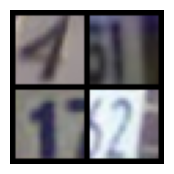

Plotting image shape: torch.Size([3, 25, 25])


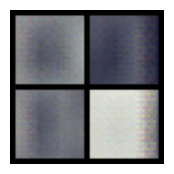

SSIM simalarity: -0.00


Epoch 3/10: 100%|██████████| 573/573 [00:05<00:00, 109.35it/s, Loss=0.0121] 


Epoch [3/10] Average Loss: 0.0001
Displaying images (Before/After reconstruction)
Plotting image shape: torch.Size([3, 25, 25])


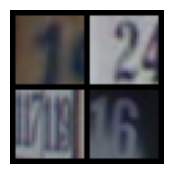

Plotting image shape: torch.Size([3, 25, 25])


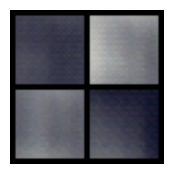

SSIM simalarity: -0.14


Epoch 4/10: 100%|██████████| 573/573 [00:05<00:00, 109.66it/s, Loss=0.00997]


Epoch [4/10] Average Loss: 0.0001
Displaying images (Before/After reconstruction)
Plotting image shape: torch.Size([3, 25, 25])


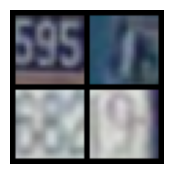

Plotting image shape: torch.Size([3, 25, 25])


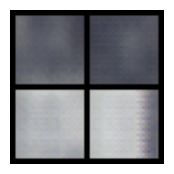

SSIM simalarity: 0.20


Epoch 5/10: 100%|██████████| 573/573 [00:05<00:00, 109.52it/s, Loss=0.0109] 


Epoch [5/10] Average Loss: 0.0001
Displaying images (Before/After reconstruction)
Plotting image shape: torch.Size([3, 25, 25])


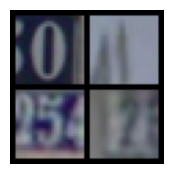

Plotting image shape: torch.Size([3, 25, 25])


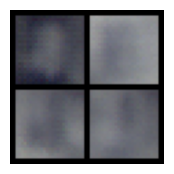

SSIM simalarity: 0.32


Epoch 6/10: 100%|██████████| 573/573 [00:05<00:00, 109.07it/s, Loss=0.00813]


Epoch [6/10] Average Loss: 0.0001
Displaying images (Before/After reconstruction)
Plotting image shape: torch.Size([3, 25, 25])


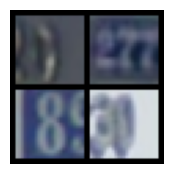

Plotting image shape: torch.Size([3, 25, 25])


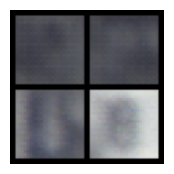

SSIM simalarity: 0.48


Epoch 7/10: 100%|██████████| 573/573 [00:05<00:00, 109.21it/s, Loss=0.00902]


Epoch [7/10] Average Loss: 0.0001
Displaying images (Before/After reconstruction)
Plotting image shape: torch.Size([3, 25, 25])


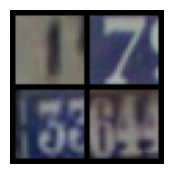

Plotting image shape: torch.Size([3, 25, 25])


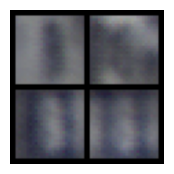

SSIM simalarity: -0.00


Epoch 8/10: 100%|██████████| 573/573 [00:05<00:00, 108.86it/s, Loss=0.00829]


Epoch [8/10] Average Loss: 0.0001
Displaying images (Before/After reconstruction)
Plotting image shape: torch.Size([3, 25, 25])


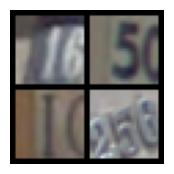

Plotting image shape: torch.Size([3, 25, 25])


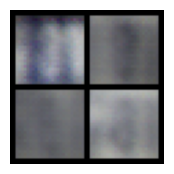

SSIM simalarity: 0.36


Epoch 9/10: 100%|██████████| 573/573 [00:05<00:00, 108.36it/s, Loss=0.00848]


Epoch [9/10] Average Loss: 0.0001
Displaying images (Before/After reconstruction)
Plotting image shape: torch.Size([3, 25, 25])


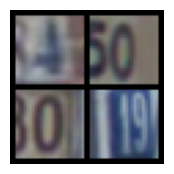

Plotting image shape: torch.Size([3, 25, 25])


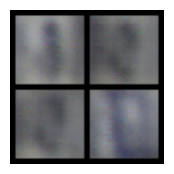

SSIM simalarity: 0.40


Epoch 10/10: 100%|██████████| 573/573 [00:05<00:00, 109.05it/s, Loss=0.00834]


Epoch [10/10] Average Loss: 0.0001
Displaying images (Before/After reconstruction)
Plotting image shape: torch.Size([3, 25, 25])


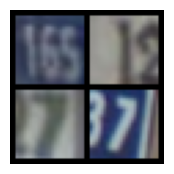

Plotting image shape: torch.Size([3, 25, 25])


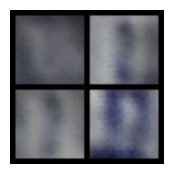

SSIM simalarity: 0.42


In [11]:
# Training Loop
sample_images = []

# initial images before reconstruction
images_org = []

# loss
average_loss_values = []

# ssim
ssim_values = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0

    # Use tqdm for the progress bar
    pbar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f'Epoch {epoch+1}/{num_epochs}')

    for batch_idx, (data, _) in pbar:
        data = data.to(device)
        images_org.append(data)

        optimizer.zero_grad()
        recon_batch, vq_loss = model(data)
        sample_images.append(data)
        
        loss = _get_vq_loss(recon_batch, data, vq_loss)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
        

        # Update tqdm description with current loss
        pbar.set_postfix({'Loss': loss.item()})

    avg_loss = train_loss / len(train_loader.dataset)
    average_loss_values.append(avg_loss)
    print(f'Epoch [{epoch + 1}/{num_epochs}] Average Loss: {avg_loss:.4f}')

    # Save and display a sample of the reconstructed images. Display last batch
    # if (epoch + 1) % 10 == 0:
    print("Displaying images (Before/After reconstruction)")
    with torch.no_grad():
        recon_batch, _ = model(data)
        show_image(data.cpu())
        show_image(recon_batch.cpu())
        
        sample_image = data[0].squeeze().cpu().numpy()
        recon_batch_image = recon_batch[0].squeeze().cpu().numpy()
        recon_min_value = recon_batch_image.min()
        recon_max_value = recon_batch_image.max()
        
        ssmi_value = ssim(
            sample_image, 
            recon_batch_image, 
            data_range=recon_max_value - recon_min_value,
            win_size=3
        )
        print(f"SSIM simalarity: {ssmi_value:.2f}")
        ssim_values.append(ssmi_value)

/tmp/ipykernel_1725187/2445385629.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Printing average loss


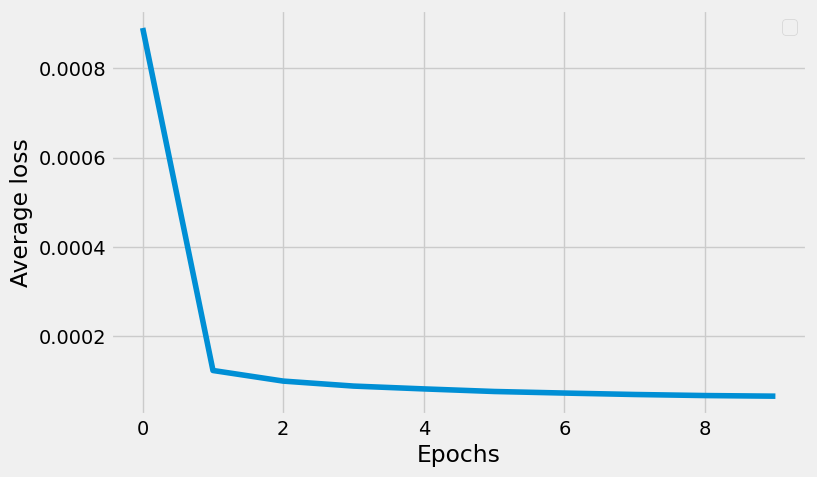

In [12]:
epoch_values = list(range(num_epochs))

def plot_loss_results(loss: list[float], epochs: int) -> None:
    print("Printing average loss")
    plt.style.use('fivethirtyeight')
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, loss)
    plt.xlabel('Epochs')
    plt.ylabel('Average loss')
    plt.legend()
    plt.show()

plot_loss_results(average_loss_values, epoch_values)

/tmp/ipykernel_1725187/3037808170.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


ssmi values over epochs


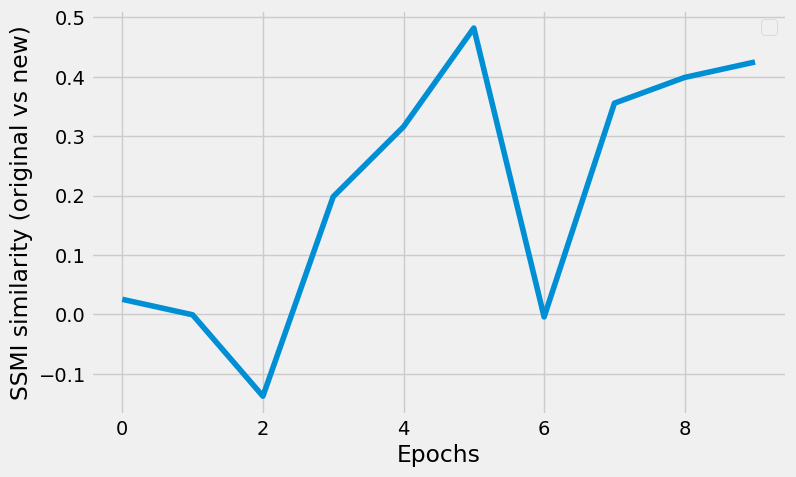

In [13]:
epoch_values = list(range(num_epochs))

def plot_ssim_results(ssim_values: list[float], epochs: int) -> None:
    print("ssmi values over epochs")
    plt.style.use('fivethirtyeight')
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, ssim_values)
    plt.xlabel('Epochs')
    plt.ylabel('SSMI similarity (original vs new)')
    plt.legend()
    plt.show()

plot_ssim_results(ssim_values, epoch_values)